# Fractal Interpolation Function using Random Iteration Algorithm

We are given interpolation data

$$
\{(x_n,y_n)\}_{n=0}^{N}
$$

with

$$
x_0 < x_1 < \cdots < x_N
$$

and vertical scaling parameters

$$
\{\alpha_n\}_{n=1}^{N}
$$

satisfying

$$
|\alpha_n| < 1
$$

We define affine transformations

$$
w_n(x,y)
=
\begin{pmatrix}
L_n(x) \\
F_n(x,y)
\end{pmatrix}
$$

where

$$
L_n(x)=a_nx+b_n
$$

and

$$
F_n(x,y)=\alpha_n y+c_nx+d_n
$$

The coefficients are determined using the join-up conditions.

In [115]:
import numpy as np
import matplotlib.pyplot as plt

# Step 1 : Input the interpolation data

We specify the interpolation points

$$
(x_0,y_0),(x_1,y_1),\dots,(x_N,y_N)
$$

and vertical scaling factors

$$
\alpha_1,\alpha_2,\dots,\alpha_N
$$

In [116]:
def phi(a, b, c):
    """Eq. (10): phi_i(a) = sqrt(c^2 + (a - b)^2)."""
    return np.sqrt(c**2 + (a - b) ** 2)

In [ ]:
def phi_i(x, xi, c):
    
    return np.sqrt(c**2 + (x - xi) ** 2)

In [117]:
# Interpolation points
# x = np.array([0, 1, 2, 3, 4], dtype=float)
# y = np.array([0, 2, 1, 3, 0], dtype=float)
x = np.linspace(0, 1, 11)
i = np.arange(len(x))

y = phi(x, i, 0.5)
# Vertical scaling factors
# alpha = np.array([0.3, -0.4, 0.2, -0.05], dtype=float)
alpha = np.array([0.3, -0.4, 0.2, -0.5, 0.1, -0.2, 0.5, -0.1, 0.2, -0.5], dtype=float)

# Number of affine maps
N = len(x) - 1

print(x)
print(y)

[0.  0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9 1. ]
[0.5        1.02956301 1.86815417 2.74590604 3.63455637 4.52769257
 5.42309875 6.31981012 7.21734023 8.11541743 9.01387819]


# Step 2 : Define endpoints

The interval is

$$
I=[x_0,x_N]
$$

The endpoint values are used in the coefficient formulas.

In [118]:
x0 = x[0]
xN = x[-1]

y0 = y[0]
yN = y[-1]

# Step 3 : Compute the coefficients

The affine maps satisfy

$$
L_n(x_0)=x_{n-1}
$$

and

$$
L_n(x_N)=x_n
$$

Hence,

$$
a_n=\frac{x_n-x_{n-1}}{x_N-x_0}
$$

$$
b_n=\frac{x_Nx_{n-1}-x_0x_n}{x_N-x_0}
$$

The vertical maps satisfy

$$
F_n(x_0,y_0)=y_{n-1}
$$

and

$$
F_n(x_N,y_N)=y_n
$$

Therefore,

$$
c_n=
\frac{
y_n-y_{n-1}
-\alpha_n(y_N-y_0)
}{
x_N-x_0
}
$$

and

$$
d_n=
\frac{
x_Ny_{n-1}
-x_0y_n
-\alpha_n(x_Ny_0-x_0y_N)
}{
x_N-x_0
}
$$

In [119]:
a = np.zeros(N)
b = np.zeros(N)

c = np.zeros(N)
d = np.zeros(N)

for n in range(N):

    xn_minus_1 = x[n]
    xn = x[n+1]

    yn_minus_1 = y[n]
    yn = y[n+1]

    alpha_n = alpha[n]

    # Compute a_n
    a[n] = (xn - xn_minus_1) / (xN - x0)

    # Compute b_n
    b[n] = (xN*xn_minus_1 - x0*xn) / ( xN - x0 )

    # Compute c_n
    c[n] = (yn - yn_minus_1 - alpha_n*(yN - y0)) / (xN - x0)

    # Compute d_n
    d[n] = (xN*yn_minus_1 - x0*yn - alpha_n*(xN*y0 - x0*yN)) / (xN - x0)

# Step 4 : Define the affine transformations

Each affine transformation is

$$
w_n(x,y)
=
\begin{pmatrix}
a_nx+b_n \\
\alpha_n y+c_nx+d_n
\end{pmatrix}
$$

In [120]:
def w(n, point):

    x_current, y_current = point

    # Horizontal transformation
    new_x = (a[n]*x_current + b[n])

    # Vertical transformation
    new_y = (alpha[n]*y_current + c[n]*x_current + d[n])

    return np.array([new_x, new_y])

# Step 5 : Random Iteration Algorithm

The Random Iteration Algorithm generates a sequence

$$
(X_k,Y_k)
$$

using

$$
(X_{k+1},Y_{k+1})
=
w_{i_k}(X_k,Y_k)
$$

where

$$
i_k \in \{1,2,\dots,N\}
$$

is selected randomly at every iteration.

Unlike the deterministic algorithm, only one affine map is applied at each step.

As the number of iterations increases, the generated points converge to the attractor of the Iterated Function System.

In [121]:
# Number of iterations
num_iterations = 200000

# Store generated points
points = np.zeros((num_iterations, 2))

# Initial point
current_point = np.array([x0, y0], dtype=float)

# Random Iteration Algorithm
for k in range(num_iterations):

    # Randomly select affine map
    n = np.random.randint(0, N)

    # Apply transformation
    current_point = w(n, current_point)

    # Store generated point
    points[k] = current_point

# Step 6 : Plot the attractor

The generated point cloud approximates the graph of the fractal interpolation function.

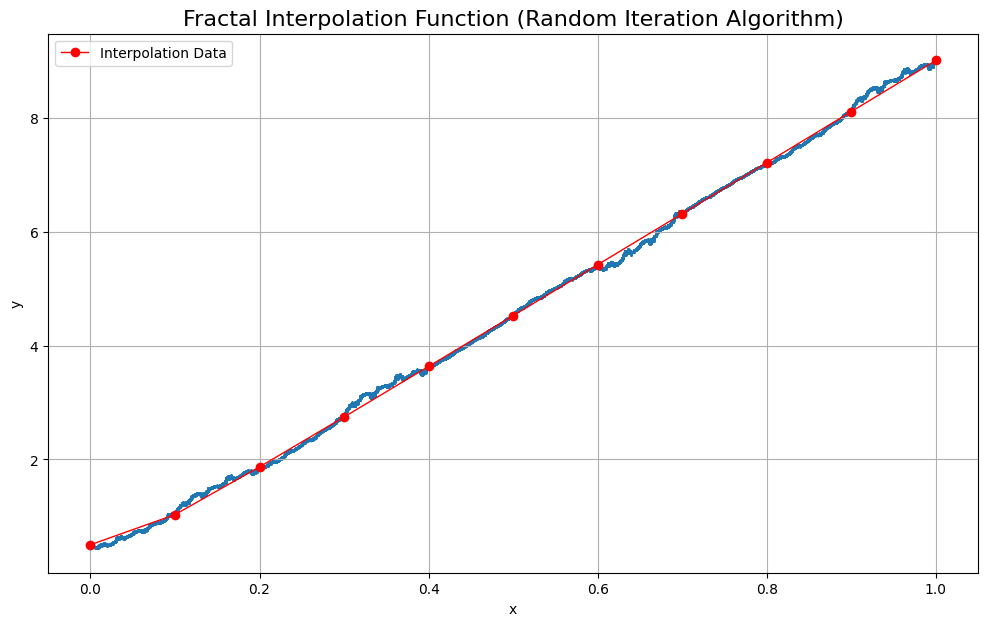

In [122]:
plt.figure(figsize=(12,7))

# Plot fractal points

plt.scatter(
    points[:,0],
    points[:,1],
    s=0.11
)

# Plot interpolation points

plt.plot(
    x,
    y,
    'ro-',
    linewidth=1,
    markersize=6,
    label='Interpolation Data'
)

plt.title(
    "Fractal Interpolation Function (Random Iteration Algorithm)",
    fontsize=16
)

plt.xlabel("x")
plt.ylabel("y")
plt.grid(True)
plt.legend()
plt.show()

# Important Difference from Deterministic Algorithm

In the deterministic algorithm:

$$
A_{k+1}
=
\bigcup_{n=1}^{N} w_n(A_k)
$$

All maps are applied to all points.

---

In the random iteration algorithm:

$$
X_{k+1}=w_{i_k}(X_k)
$$

Only one randomly selected map is applied at each iteration.

---

## Advantages of Random Iteration Algorithm

- Extremely fast
- Memory efficient
- Produces high-resolution attractors
- Suitable for large iteration counts

---

## Important Condition

The contractivity condition

$$
|\alpha_n|<1
$$

must hold for all

$$
n=1,2,\dots,N
$$

to guarantee existence of the attractor.